In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# define file paths 
MODEL_TABLE_PATH = "../data/results/modelling_table.csv"
MNLG_TABLE_PATH = "../data/results/mn_logreg_evaluation.csv"

# load datasets 
model_df = pd.read_csv(MODEL_TABLE_PATH, index_col="date")  # main modelling table with sentiment and returns
mnlg_df = pd.read_csv(MNLG_TABLE_PATH)  # multinomial logistic regression evaluation metrics

## Exploratory Data Analysis 
This notebook will explore the modelling table of financial and social data to explore its relationships and patterns

### Modelling Table

In [14]:
display(model_df)

,GLD,SPY,USO,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY,mean_fb_score
date,,,,,,,,,,,,,,,
2019-01-03,1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.0,0.0,-1.0,-1.0,-0.102725
2019-01-04,-1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-0.007578
2019-01-07,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,-1.0,1.0,1.0,0.056656
2019-01-08,-1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.036152
2019-01-09,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,-1.0,-1.0,-1.0,1.0,1.0,0.014667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-12-23,1.0,0.0,1.0,1.0,-1.0,1.0,-1.0,1.0,1.0,-1.0,-1.0,-1.0,1.0,-1.0,0.094960
2019-12-24,1.0,0.0,1.0,0.0,0.0,0.0,1.0,-1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.068481
2019-12-26,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.124986


#### Evaluation Table

In [15]:
display(mnlg_df)

,ticker,accuracy_mean,f1_macro_mean,cm_00,cm_01,cm_02,cm_10,cm_11,cm_12,cm_20,cm_21,cm_22,n_samples
0,GLD,0.331707,0.299642,31,10,25,23,13,12,51,16,24,248
1,SPY,0.439024,0.366724,14,21,21,10,14,32,13,18,62,248
2,USO,0.380488,0.311740,18,23,37,7,8,14,20,26,52,248
3,XLB,0.468293,0.377500,25,12,33,9,9,22,19,14,62,248
4,XLC,0.531707,0.486182,28,20,17,10,18,13,22,14,63,248
5,XLE,0.443902,0.388546,31,28,23,6,10,22,12,23,50,248
6,XLF,0.429268,0.350932,25,24,25,7,6,17,21,23,57,248
7,XLI,0.448780,0.398605,20,28,21,1,21,23,18,22,51,248
8,XLK,0.560976,0.454892,30,15,20,6,6,24,10,15,79,248
9,XLP,0.370732,0.314095,10,26,19,8,21,31,13,32,45,248


### Modelling Table Visualizations

#### Time Series of Sentiment Scores

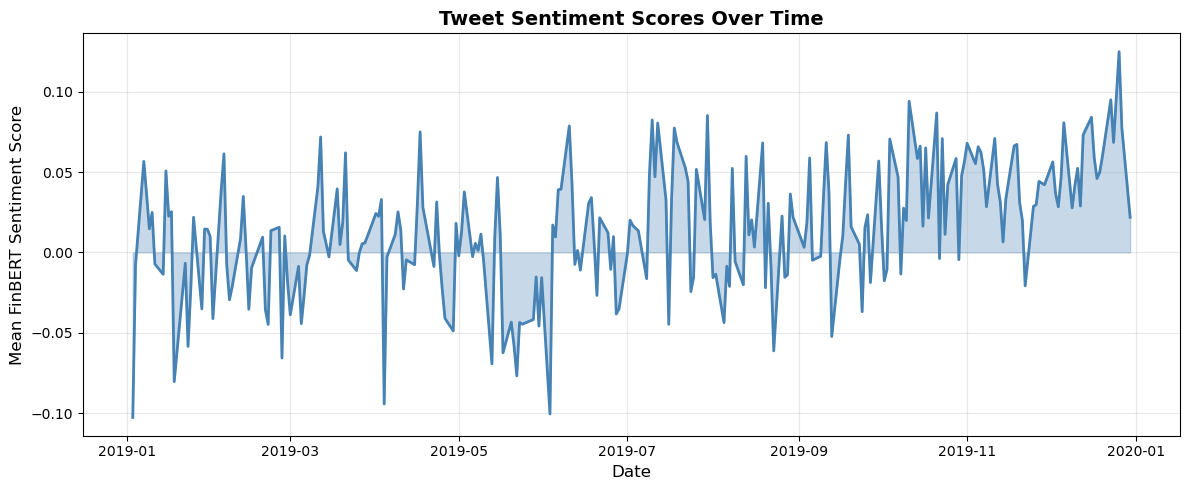

In [16]:
# convert date index to datetime for proper plotting
model_df.index = pd.to_datetime(model_df.index)

# create time series plot of sentiment scores
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(model_df.index, model_df['mean_fb_score'], linewidth=2, color='steelblue')
ax.fill_between(model_df.index, model_df['mean_fb_score'], alpha=0.3, color='steelblue')

# format axes and add labels
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Mean FinBERT Sentiment Score', fontsize=12)
ax.set_title('Tweet Sentiment Scores Over Time', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

### Evaluation Table Visualizations

#### Accuracy Across Sectors

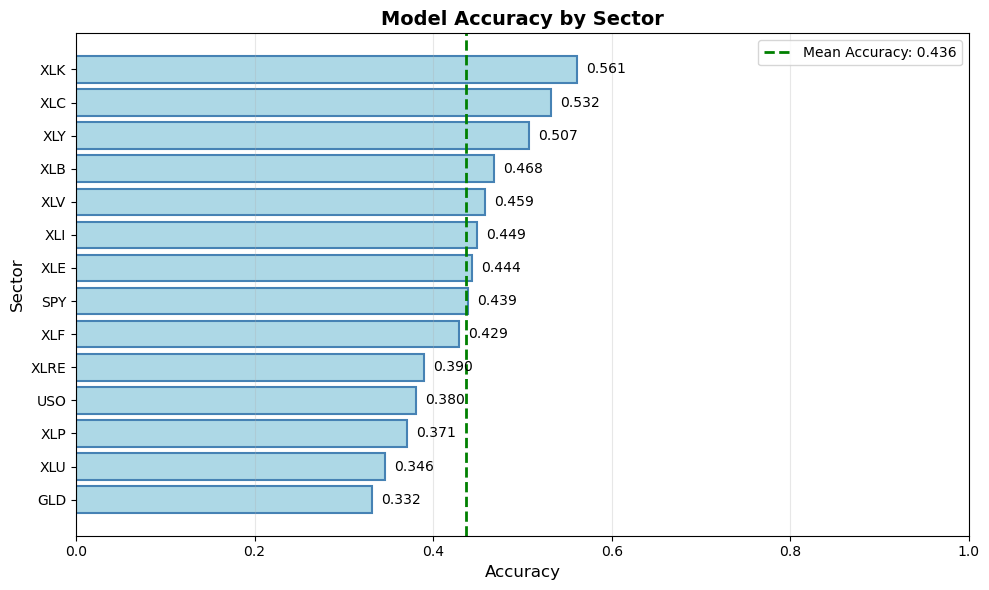

In [17]:
# sort sectors by accuracy 
sorted_df = mnlg_df.sort_values('accuracy_mean', ascending=True)

# create horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(sorted_df['ticker'], sorted_df['accuracy_mean'], color='lightblue', edgecolor='steelblue', linewidth=1.5)

# add accuracy value labels to each bar
for i, (ticker, accuracy) in enumerate(zip(sorted_df['ticker'], sorted_df['accuracy_mean'])):
    ax.text(accuracy + 0.01, i, f'{accuracy:.3f}', va='center', fontsize=10)

# add vertical line showing mean accuracy
mean_accuracy = mnlg_df['accuracy_mean'].mean()
ax.axvline(mean_accuracy, color='green', linestyle='--', linewidth=2, label=f'Mean Accuracy: {mean_accuracy:.3f}')

# format axes and add labels
ax.set_xlabel('Accuracy', fontsize=12)
ax.set_ylabel('Sector', fontsize=12)
ax.set_title('Model Accuracy by Sector', fontsize=14, fontweight='bold')
ax.set_xlim(0, 1)
ax.legend()
ax.grid(True, alpha=0.3, axis='x')

fig.tight_layout()
plt.show()

#### Confusion Matrices by Sector

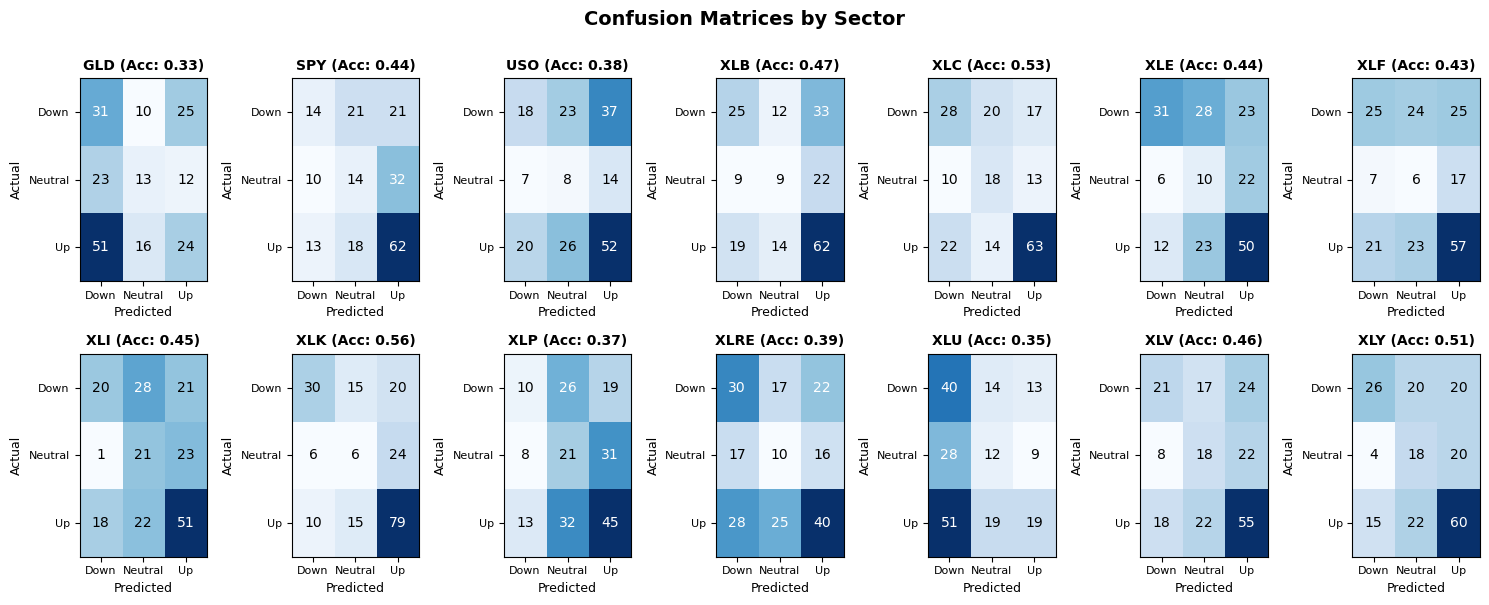

In [ ]:
# extract confusion matrix columns and define class labels
cm_cols = [col for col in mnlg_df.columns if col.startswith('cm_')]
class_labels = ['Down', 'Neutral', 'Up']

# create grid of subplots 
fig, axes = plt.subplots(2, 7, figsize=(15, 6))
axes = axes.flatten()

# generate a confusion matrix heatmap for each sector
for idx, row in mnlg_df.iterrows():
    ax = axes[idx]
    
    # put the confusion matrix values into a 3x3 grid
    cm = np.array([row[col] for col in cm_cols]).reshape(3, 3)
    
    # create heatmap with blue colors
    im = ax.imshow(cm, cmap='Blues', aspect='auto')
    
    # set axis ticks and labels
    ax.set_xticks(np.arange(3))
    ax.set_yticks(np.arange(3))
    ax.set_xticklabels(class_labels, fontsize=8)
    ax.set_yticklabels(class_labels, fontsize=8)
    ax.set_ylabel('Actual', fontsize=9)
    ax.set_xlabel('Predicted', fontsize=9)
    
    # add count annotations to each cell
    for i in range(3):
        for j in range(3):
            text = ax.text(j, i, int(cm[i, j]), ha="center", va="center", 
                          color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=10)
    
    # add sector name and accuracy to subplot title
    ax.set_title(f'{row["ticker"]} (Acc: {row["accuracy_mean"]:.2f})', fontsize=10, fontweight='bold')

plt.suptitle('Confusion Matrices by Sector', fontsize=14, fontweight='bold', y=1.00)
fig.tight_layout()
plt.show()